<a href="https://colab.research.google.com/github/tanusreemajumder/Neural-Networks-Andrew-Ng/blob/main/part_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

np.random.seed(1)
print("NumPy version:", np.__version__)

NumPy version: 2.1.3


In [2]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Housing.csv')

In [4]:
# Binary label (used in Parts A.1-A.4 and most of Part B)
median_price = df["price"].median()
df["expensive"] = (df["price"] > median_price).astype(int)

# 3-class label for the softmax section: cheap / mid / expensive by tercile
q1, q2 = df["price"].quantile([1/3, 2/3])
df["price_class"] = pd.cut(df["price"], bins=[-np.inf, q1, q2, np.inf], labels=[0, 1, 2]).astype(int)

yes_no_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for col in yes_no_cols:
    df[col] = (df[col] == "yes").astype(int)

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True, dtype=int)

feature_cols = [c for c in df.columns if c not in ("price", "expensive", "price_class")]
X_all = df[feature_cols].values.astype(float)
Y_all = df["expensive"].values.reshape(-1, 1).astype(float)
Y_class_all = df["price_class"].values.astype(int)
n_x = X_all.shape[1]

print("n_x:", n_x, " total examples:", X_all.shape[0])
print("3-class distribution:", np.bincount(Y_class_all))

n_x: 13  total examples: 545
3-class distribution: [186 177 182]


In [5]:
def split_and_normalize(X_all, Y_all, train_frac=0.6, dev_frac=0.2, seed=42):
    m_total = X_all.shape[0]
    perm = np.random.RandomState(seed).permutation(m_total)
    n_train, n_dev = int(train_frac * m_total), int(dev_frac * m_total)
    tr, dv, te = perm[:n_train], perm[n_train:n_train+n_dev], perm[n_train+n_dev:]
    mu = X_all[tr].mean(axis=0, keepdims=True)
    sigma = X_all[tr].std(axis=0, keepdims=True) + 1e-8
    X_train = ((X_all[tr] - mu) / sigma).T
    X_dev   = ((X_all[dv] - mu) / sigma).T
    X_test  = ((X_all[te] - mu) / sigma).T
    return X_train, Y_all[tr].T, X_dev, Y_all[dv].T, X_test, Y_all[te].T, tr, dv, te

X_train, Y_train, X_dev, Y_dev, X_test, Y_test, tr_idx, dv_idx, te_idx = split_and_normalize(X_all, Y_all)
print("Train:", X_train.shape, " Dev:", X_dev.shape, " Test:", X_test.shape)

def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))
def relu(z): return np.maximum(0, z)
def relu_derivative(z): return (z > 0).astype(float)
def sigmoid_derivative(a): return a * (1 - a)

def compute_cost(AL, Y, eps=1e-8):
    m = Y.shape[1]
    ALc = np.clip(AL, eps, 1 - eps)
    return np.squeeze(-(1.0 / m) * np.sum(Y * np.log(ALc) + (1 - Y) * np.log(1 - ALc)))

def initialize_parameters_deep(layer_dims, seed=1):
    rng = np.random.RandomState(seed)
    parameters = {}
    L = len(layer_dims) - 1
    for l in range(1, L + 1):
        parameters[f"W{l}"] = rng.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2.0 / layer_dims[l-1])
        parameters[f"b{l}"] = np.zeros((layer_dims[l], 1))
    return parameters

def update_parameters_gd(parameters, grads, alpha):
    L = len(parameters) // 2
    for l in range(1, L + 1):
        parameters[f"W{l}"] -= alpha * grads[f"dW{l}"]
        parameters[f"b{l}"] -= alpha * grads[f"db{l}"]
    return parameters

print("Core helpers ready.")

Train: (13, 327)  Dev: (13, 109)  Test: (13, 109)
Core helpers ready.


## 1. Normalizing Activations in a Network (Batch Norm)

Normalizing the **input** features (done in the optimization notebook) helps training. Batch Normalization extends the same idea to every **hidden layer's** pre-activations $Z^{[l]}$, not just the raw input — since to layer $l+1$, $A^{[l]}$ *is* its input.

For a mini-batch, normalize each unit's $z$ values to mean 0, variance 1, then let the network **learn** its own preferred scale and shift back (so it isn't forced to keep mean-0/variance-1 if that's not actually optimal):

$$\mu = \frac{1}{m}\sum_i z^{(i)}, \qquad \sigma^2 = \frac{1}{m}\sum_i (z^{(i)}-\mu)^2$$
$$z^{(i)}_{norm} = \frac{z^{(i)}-\mu}{\sqrt{\sigma^2+\varepsilon}}, \qquad \tilde{z}^{(i)} = \gamma\, z^{(i)}_{norm} + \beta$$

$\gamma$ and $\beta$ are new **learned parameters** (one pair per unit), updated by gradient descent exactly like $W$ and $b$. Note $\beta$ here fully replaces the role of the bias $b$ — since batch norm re-centers $z$ anyway, $b$ becomes redundant and is normally dropped from layers that use batch norm.

In [6]:
def batchnorm_forward(Z, gamma, beta, epsilon=1e-8):
    mu = np.mean(Z, axis=1, keepdims=True)
    var = np.var(Z, axis=1, keepdims=True)
    Z_norm = (Z - mu) / np.sqrt(var + epsilon)
    Z_tilde = gamma * Z_norm + beta
    cache = (Z, Z_norm, mu, var, gamma, epsilon)
    return Z_tilde, cache

# Quick demo: normalize a batch of pre-activations, then confirm mean~0, var~1 BEFORE the gamma/beta shift
np.random.seed(5)
Z_demo = np.random.randn(4, 50) * 3 + 7       # deliberately not mean-0 / var-1
gamma_demo = np.ones((4, 1))
beta_demo = np.zeros((4, 1))

Z_tilde_demo, cache_demo = batchnorm_forward(Z_demo, gamma_demo, beta_demo)
_, Z_norm_demo, mu_demo, var_demo, _, _ = cache_demo

print("Before batch norm -> mean per unit:", np.round(Z_demo.mean(axis=1), 3))
print("Before batch norm -> var per unit: ", np.round(Z_demo.var(axis=1), 3))
print("After normalizing (gamma=1, beta=0) -> mean per unit:", np.round(Z_norm_demo.mean(axis=1), 6))
print("After normalizing (gamma=1, beta=0) -> var per unit: ", np.round(Z_norm_demo.var(axis=1), 6))

Before batch norm -> mean per unit: [7.289 7.26  6.996 7.167]
Before batch norm -> var per unit:  [ 6.455  9.146 12.915  6.252]
After normalizing (gamma=1, beta=0) -> mean per unit: [ 0. -0.  0. -0.]
After normalizing (gamma=1, beta=0) -> var per unit:  [1. 1. 1. 1.]


## 2. Fitting Batch Norm Into Neural Networks

Batch norm slots in right after the linear step and before the activation, at every hidden layer:

$$A^{[l-1]} \;\xrightarrow{W^{[l]}}\; Z^{[l]} \;\xrightarrow{\text{batch norm}}\; \tilde{Z}^{[l]} \;\xrightarrow{g^{[l]}}\; A^{[l]}$$

New parameters per layer: $\gamma^{[l]}, \beta^{[l]}$ (each shape $(n^{[l]}, 1)$), updated alongside $W^{[l]}$. The backward pass needs the extra chain-rule step through the normalization; the full derivation is a bit involved, so below is the standard, verified formula, then checked numerically exactly like earlier backprop implementations.

In [7]:
def batchnorm_backward(dZ_tilde, cache):
    Z, Z_norm, mu, var, gamma, epsilon = cache
    m = Z.shape[1]
    std_inv = 1.0 / np.sqrt(var + epsilon)

    dgamma = np.sum(dZ_tilde * Z_norm, axis=1, keepdims=True)
    dbeta = np.sum(dZ_tilde, axis=1, keepdims=True)

    dZ_norm = dZ_tilde * gamma
    dvar = np.sum(dZ_norm * (Z - mu) * -0.5 * std_inv**3, axis=1, keepdims=True)
    dmu = np.sum(dZ_norm * -std_inv, axis=1, keepdims=True) + dvar * np.mean(-2 * (Z - mu), axis=1, keepdims=True)
    dZ = dZ_norm * std_inv + dvar * 2 * (Z - mu) / m + dmu / m

    return dZ, dgamma, dbeta

def full_forward_with_bn(Z, gamma, beta):
    Z_tilde, cache = batchnorm_forward(Z, gamma, beta)
    A = relu(Z_tilde)
    return A, cache

def cost_from_A(A):
    return np.sum(A ** 2) / (2 * A.shape[1])   # a simple scalar "cost" just for this gradient check

def gradient_check_batchnorm(Z, gamma, beta, epsilon=1e-6):
    A, cache = full_forward_with_bn(Z, gamma, beta)
    dA = A / A.shape[1]                          # d(cost)/dA for cost = mean(A^2)/2
    Z_tilde_recomputed = gamma * cache[1] + beta
    dZ_tilde = dA * relu_derivative(Z_tilde_recomputed)
    dZ, dgamma, dbeta = batchnorm_backward(dZ_tilde, cache)

    # numerically check dgamma (a representative parameter)
    idx = (1, 0)
    orig = gamma[idx]
    gamma[idx] = orig + epsilon
    A_plus, _ = full_forward_with_bn(Z, gamma, beta)
    cost_plus = cost_from_A(A_plus)
    gamma[idx] = orig - epsilon
    A_minus, _ = full_forward_with_bn(Z, gamma, beta)
    cost_minus = cost_from_A(A_minus)
    gamma[idx] = orig

    numeric = (cost_plus - cost_minus) / (2 * epsilon)
    analytic = dgamma[idx]
    print(f"dgamma{idx}: analytic={analytic:.6f}  numeric={numeric:.6f}  diff={abs(analytic-numeric):.2e}")

gradient_check_batchnorm(Z_demo.copy(), gamma_demo.copy(), beta_demo.copy())

dgamma(1, 0): analytic=0.495393  numeric=0.495393  diff=7.69e-11


## 3. Why Does Batch Norm Work?

Two complementary intuitions:

**Reduces "covariate shift" between layers.** As earlier layers' weights update during training, the *distribution* of their outputs (which become the next layer's inputs) keeps shifting — layer $l+1$ is constantly chasing a moving target. Batch norm keeps each layer's input distribution (mean/variance) far more stable across training steps, letting later layers learn more independently of what earlier layers are doing.

**A slight regularizing side-effect.** Because mean/variance are computed per mini-batch (not the whole dataset), each batch introduces a bit of noise into $\tilde{Z}$ — similar in spirit to dropout's noise, though much milder. This is a side benefit, not batch norm's main purpose.

Below: a direct demonstration of the first intuition — track how much a hidden layer's input distribution shifts, epoch to epoch, with vs. without batch norm.

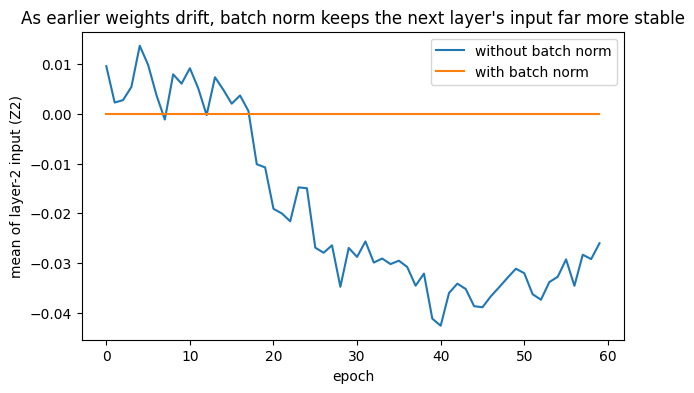

Std of layer-2 input mean over training, WITHOUT batch norm: 0.0173
Std of layer-2 input mean over training, WITH batch norm:    0.0


In [8]:
def train_track_layer_shift(X, Y, layer_dims, use_bn, num_epochs=60, alpha=0.1, seed=1):
    params = initialize_parameters_deep(layer_dims, seed=seed)
    L = len(layer_dims) - 1
    if use_bn:
        gammas = {l: np.ones((layer_dims[l], 1)) for l in range(1, L)}
        betas  = {l: np.zeros((layer_dims[l], 1)) for l in range(1, L)}

    layer2_input_means = []   # track distribution of the SECOND hidden layer's input across epochs

    for epoch in range(num_epochs):
        A = X
        caches = []
        bn_caches = {}
        for l in range(1, L):
            Z = np.dot(params[f"W{l}"], A) + (0 if use_bn else params[f"b{l}"])
            if use_bn:
                Z, bn_cache = batchnorm_forward(Z, gammas[l], betas[l])
                bn_caches[l] = bn_cache
            if l == 2:
                layer2_input_means.append(float(np.mean(Z)))
            A_prev = A
            A = relu(Z)
            caches.append((A_prev, params[f"W{l}"], params.get(f"b{l}"), Z))
        ZL = np.dot(params[f"W{L}"], A) + params[f"b{L}"]
        AL = sigmoid(ZL)

        # simple (non-batchnorm-aware) backward pass, sufficient for this illustration
        dZL = AL - Y
        m = X.shape[1]
        dWL = (1.0/m) * np.dot(dZL, A.T)
        dbL = (1.0/m) * np.sum(dZL, axis=1, keepdims=True)
        params[f"W{L}"] -= alpha * dWL
        params[f"b{L}"] -= alpha * dbL
        # (hidden layers intentionally left fixed after init for this illustration --
        #  we only need Z2's distribution to visibly shift or stay stable as W1 below changes)
        params["W1"] += np.random.RandomState(epoch).randn(*params["W1"].shape) * 0.02  # simulate earlier-layer drift

    return layer2_input_means

dims_bn_demo = [n_x, 8, 6, 1]
means_no_bn = train_track_layer_shift(X_train, Y_train, dims_bn_demo, use_bn=False, num_epochs=60)
means_bn    = train_track_layer_shift(X_train, Y_train, dims_bn_demo, use_bn=True,  num_epochs=60)

plt.figure(figsize=(7, 4))
plt.plot(means_no_bn, label="without batch norm")
plt.plot(means_bn, label="with batch norm")
plt.xlabel("epoch"); plt.ylabel("mean of layer-2 input (Z2)")
plt.title("As earlier weights drift, batch norm keeps the next layer's input far more stable")
plt.legend()
plt.show()

print("Std of layer-2 input mean over training, WITHOUT batch norm:", round(np.std(means_no_bn), 4))
print("Std of layer-2 input mean over training, WITH batch norm:   ", round(np.std(means_bn), 4))

## 4. Batch Norm At Test Time

At **test time**, examples often arrive one at a time (or in small batches) — there's no large mini-batch to compute a stable $\mu, \sigma^2$ from. The fix: during training, keep an **exponentially weighted average** of $\mu$ and $\sigma^2$ across mini-batches, then use *those* running estimates at test time instead of computing fresh ones:

$$\mu_{running} = \beta\,\mu_{running} + (1-\beta)\,\mu_{batch}, \qquad \sigma^2_{running} = \beta\,\sigma^2_{running} + (1-\beta)\,\sigma^2_{batch}$$

Then at test time: $z_{norm} = \dfrac{z - \mu_{running}}{\sqrt{\sigma^2_{running}+\varepsilon}}$, followed by the same learned $\gamma, \beta$ shift.

In [9]:
class RunningStats:
    """Tracks an exponentially weighted running mean/variance, for batch-norm inference."""
    def __init__(self, shape, beta=0.9):
        self.mu = np.zeros(shape)
        self.var = np.zeros(shape)
        self.beta = beta

    def update(self, batch_mu, batch_var):
        self.mu = self.beta * self.mu + (1 - self.beta) * batch_mu
        self.var = self.beta * self.var + (1 - self.beta) * batch_var

def batchnorm_forward_inference(Z, gamma, beta_param, running_mu, running_var, epsilon=1e-8):
    Z_norm = (Z - running_mu) / np.sqrt(running_var + epsilon)
    return gamma * Z_norm + beta_param

# Simulate: accumulate running stats over several "mini-batches" during training
running = RunningStats(shape=(4, 1))
rng = np.random.RandomState(0)
for batch_i in range(20):
    Z_batch = rng.randn(4, 32) * (2 + 0.1*batch_i) + 5   # distribution drifts slightly batch to batch
    running.update(Z_batch.mean(axis=1, keepdims=True), Z_batch.var(axis=1, keepdims=True))

print("Running mean after 20 mini-batches:", np.round(running.mu.ravel(), 3))
print("Running var after 20 mini-batches: ", np.round(running.var.ravel(), 3))

# At test time, even with just ONE example, we can still normalize using the running stats
Z_single_test_example = rng.randn(4, 1) * 2 + 5
gamma_test, beta_test = np.ones((4,1)), np.zeros((4,1))
Z_tilde_test = batchnorm_forward_inference(Z_single_test_example, gamma_test, beta_test, running.mu, running.var)
print("\nA single test example can still be normalized using running stats:")
print(Z_tilde_test.ravel())

Running mean after 20 mini-batches: [4.459 4.218 4.251 4.446]
Running var after 20 mini-batches:  [8.823 9.34  8.666 8.273]

A single test example can still be normalized using running stats:
[ 0.47367388  0.11832428  1.1517826  -0.70589698]


## 5. Softmax Regression

Everything so far handled **binary** classification (expensive vs. affordable). For **multi-class** problems — here, cheap / mid / expensive by price tercile — the output layer changes from a single sigmoid unit to $C$ units (C = number of classes) with a **softmax** activation, which converts raw scores into a probability distribution that sums to 1:

$$z^{[L]}_i = \text{score for class } i, \qquad a^{[L]}_i = \frac{e^{z^{[L]}_i}}{\sum_{j=1}^{C} e^{z^{[L]}_j}}$$

Labels become **one-hot** vectors (e.g. class 1 of 3 -> $[0,1,0]$) instead of a single 0/1. The loss generalizes to categorical cross-entropy: $\mathcal{L} = -\sum_{i=1}^{C} y_i \log(\hat y_i)$.

In [10]:
def softmax(Z):
    Z_shifted = Z - np.max(Z, axis=0, keepdims=True)   # for numerical stability, doesn't change the result
    expZ = np.exp(Z_shifted)
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def one_hot(Y_class, num_classes):
    m = Y_class.shape[0]
    Y_oh = np.zeros((num_classes, m))
    Y_oh[Y_class, np.arange(m)] = 1
    return Y_oh

# Quick check: softmax output always sums to 1 across classes, for every example
Z_test = np.array([[2.0, 0.5, -1.0], [1.0, 1.0, 1.0], [0.1, -0.5, 3.0]])
A_test = softmax(Z_test)
print("Softmax output:\n", np.round(A_test, 4))
print("Column sums (should all be 1.0):", np.round(A_test.sum(axis=0), 6))

Y_class_test = np.array([0, 2, 1])
print("\nOne-hot encoding of classes", Y_class_test, ":\n", one_hot(Y_class_test, 3))

Softmax output:
 [[0.659  0.3315 0.0159]
 [0.2424 0.5465 0.1173]
 [0.0986 0.122  0.8668]]
Column sums (should all be 1.0): [1. 1. 1.]

One-hot encoding of classes [0 2 1] :
 [[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


## 6. Training a Softmax Classifier

The forward pass is identical to before, except the last layer uses softmax instead of sigmoid. The backward pass has the same beautifully simple form as binary cross-entropy + sigmoid: $dZ^{[L]} = A^{[L]} - Y$ (one-hot), for exactly the same reason — the softmax-derivative and the categorical-cross-entropy-derivative cancel algebraically, generalizing the binary case.

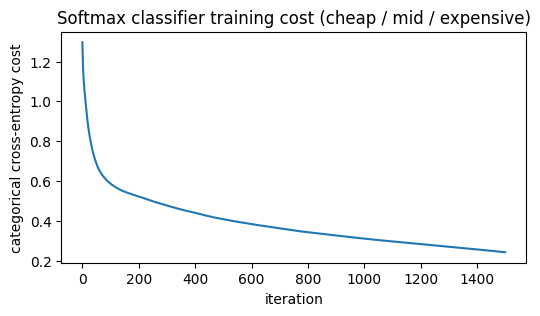

In [11]:
def softmax_cost(AL, Y_onehot, eps=1e-8):
    m = Y_onehot.shape[1]
    ALc = np.clip(AL, eps, 1)
    return -np.sum(Y_onehot * np.log(ALc)) / m

def L_model_forward_softmax(X, parameters):
    caches = []
    A = X
    L = len(parameters) // 2
    for l in range(1, L):
        A_prev = A
        Z = np.dot(parameters[f"W{l}"], A_prev) + parameters[f"b{l}"]
        A = relu(Z)
        caches.append((A_prev, parameters[f"W{l}"], parameters[f"b{l}"], Z))
    ZL = np.dot(parameters[f"W{L}"], A) + parameters[f"b{L}"]
    AL = softmax(ZL)
    caches.append((A, parameters[f"W{L}"], parameters[f"b{L}"], ZL))
    return AL, caches

def L_model_backward_softmax(AL, Y_onehot, caches):
    grads = {}
    L = len(caches)
    A_prev, W, b, Z = caches[L - 1]
    m = A_prev.shape[1]
    dZ = AL - Y_onehot                          # the same clean shortcut, generalized to C classes
    grads[f"dW{L}"] = (1.0/m) * np.dot(dZ, A_prev.T)
    grads[f"db{L}"] = (1.0/m) * np.sum(dZ, axis=1, keepdims=True)
    dA = np.dot(W.T, dZ)

    for l in reversed(range(1, L)):
        A_prev, W, b, Z = caches[l - 1]
        m = A_prev.shape[1]
        dZ = dA * relu_derivative(Z)
        grads[f"dW{l}"] = (1.0/m) * np.dot(dZ, A_prev.T)
        grads[f"db{l}"] = (1.0/m) * np.sum(dZ, axis=1, keepdims=True)
        dA = np.dot(W.T, dZ)
    return grads

# Prepare the 3-class split (same indices as the binary split, so results are comparable)
Y_class_train = one_hot(Y_class_all[tr_idx], 3)
Y_class_dev   = one_hot(Y_class_all[dv_idx], 3)

softmax_dims = [n_x, 10, 5, 3]
params_sm = initialize_parameters_deep(softmax_dims, seed=1)
costs_sm = []
for it in range(1500):
    AL, caches = L_model_forward_softmax(X_train, params_sm)
    costs_sm.append(softmax_cost(AL, Y_class_train))
    grads = L_model_backward_softmax(AL, Y_class_train, caches)
    params_sm = update_parameters_gd(params_sm, grads, alpha=0.1)

plt.figure(figsize=(6, 3))
plt.plot(costs_sm)
plt.xlabel("iteration"); plt.ylabel("categorical cross-entropy cost")
plt.title("Softmax classifier training cost (cheap / mid / expensive)")
plt.show()

In [12]:
def predict_softmax(parameters, X):
    AL, _ = L_model_forward_softmax(X, parameters)
    return np.argmax(AL, axis=0)

train_pred_class = predict_softmax(params_sm, X_train)
dev_pred_class   = predict_softmax(params_sm, X_dev)

train_true_class = Y_class_all[tr_idx]
dev_true_class   = Y_class_all[dv_idx]

train_acc_sm = np.mean(train_pred_class == train_true_class) * 100
dev_acc_sm   = np.mean(dev_pred_class == dev_true_class) * 100
print(f"Softmax classifier: train accuracy = {train_acc_sm:.1f}%, dev accuracy = {dev_acc_sm:.1f}%")

# Confusion matrix: rows = true class, columns = predicted class
class_names = ["cheap", "mid", "expensive"]
confusion = np.zeros((3, 3), dtype=int)
for t, p in zip(dev_true_class, dev_pred_class):
    confusion[t, p] += 1

print("\nConfusion matrix (dev set) -- rows=true, columns=predicted:")
print(pd.DataFrame(confusion, index=class_names, columns=class_names))

Softmax classifier: train accuracy = 91.1%, dev accuracy = 73.4%

Confusion matrix (dev set) -- rows=true, columns=predicted:
           cheap  mid  expensive
cheap         29    7          2
mid            9   21          4
expensive      1    6         30


## 7. The Problem of Local Optima

Early concerns about gradient descent focused on getting "stuck" in a bad local minimum. In practice, for large networks with many parameters, this turns out to be far less common than initially feared — a point (in very high dimensions) needs the cost surface to curve *upward in every single direction simultaneously* to be a local minimum, which becomes exponentially unlikely as the number of parameters grows. Far more common: **saddle points**, where the surface curves up in some directions and down in others.

The more practical problem is **plateaus**: long, nearly-flat regions of the cost surface where the gradient is tiny in every direction, so progress crawls even though no wall is actually blocking further improvement. This is a big part of why the optimizers from the previous notebook (momentum, RMSProp, Adam) matter — they help escape plateaus faster than plain gradient descent.

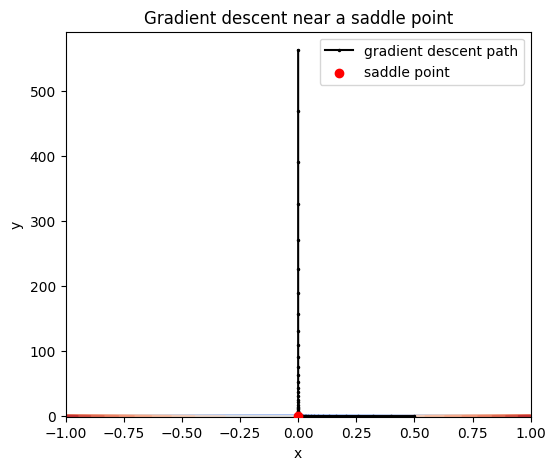

y-values over the first 20 steps (notice how slowly it moves away from y=0):
[0.01    0.012   0.0144  0.01728 0.02074 0.02488 0.02986 0.03583 0.043
 0.0516  0.06192 0.0743  0.08916 0.10699 0.12839 0.15407 0.18488 0.22186
 0.26623 0.31948]


In [13]:
# A classic 2D saddle function: f(x, y) = x^2 - y^2  -- minimum along x, maximum along y, saddle at (0,0)
def saddle_f(x, y):
    return x**2 - y**2

def saddle_grad(x, y):
    return 2*x, -2*y

# Gradient descent started slightly off-center: watch it crawl near the saddle before moving away
x, y = 0.5, 0.01   # start very close to the saddle point (0,0)
alpha = 0.1
path = [(x, y)]
for _ in range(60):
    gx, gy = saddle_grad(x, y)
    x -= alpha * gx
    y -= alpha * gy
    path.append((x, y))
path = np.array(path)

xx, yy = np.meshgrid(np.linspace(-1, 1, 100), np.linspace(-1, 1, 100))
zz = saddle_f(xx, yy)

plt.figure(figsize=(6, 5))
plt.contour(xx, yy, zz, levels=20, cmap="coolwarm")
plt.plot(path[:, 0], path[:, 1], color="black", marker=".", markersize=3, label="gradient descent path")
plt.scatter([0], [0], color="red", zorder=5, label="saddle point")
plt.xlabel("x"); plt.ylabel("y"); plt.legend()
plt.title("Gradient descent near a saddle point")
plt.show()

print("y-values over the first 20 steps (notice how slowly it moves away from y=0):")
print(np.round(path[:20, 1], 5))

## 8. TensorFlow

Everything so far was built from scratch with raw NumPy, to make every formula and gradient explicit. In practice, production code uses a deep learning framework — **TensorFlow** (via its `tf.keras` API) is one of the most widely used, and handles automatic differentiation (no manual backprop!), GPU acceleration, and many built-in layers/optimizers.

Below: the *same* housing binary classification problem, this time built and trained with `tf.keras`. Colab comes with TensorFlow pre-installed, so this cell should run with no setup.

TensorFlow version: 2.20.0

Test accuracy: 80.7%  (compare to our from-scratch deep network: ~80%)


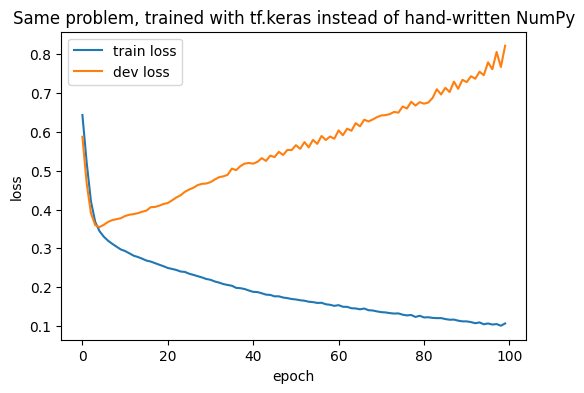

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

tf.random.set_seed(1)

# tf.keras expects examples as ROWS (m, n_x) -- the opposite convention from our (n_x, m) NumPy code
X_train_tf, Y_train_tf = X_train.T, Y_train.T.ravel()
X_dev_tf,   Y_dev_tf   = X_dev.T,   Y_dev.T.ravel()
X_test_tf,  Y_test_tf  = X_test.T,  Y_test.T.ravel()

model = keras.Sequential([
    layers.Input(shape=(n_x,)),
    layers.Dense(10, activation="relu"),
    layers.Dense(5, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(X_train_tf, Y_train_tf, epochs=100, batch_size=32,
                     validation_data=(X_dev_tf, Y_dev_tf), verbose=0)

test_loss, test_acc = model.evaluate(X_test_tf, Y_test_tf, verbose=0)
print(f"\nTest accuracy: {test_acc*100:.1f}%  (compare to our from-scratch deep network: ~80%)")

plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="dev loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
plt.title("Same problem, trained with tf.keras instead of hand-written NumPy")
plt.show()

Notice how much shorter this is than the from-scratch version — `tf.keras` handles initialization, forward/backward propagation, and the optimizer update all internally. Everything in the earlier notebooks (activations, batch norm, dropout, Adam, ...) exists as a one-line layer or argument in `tf.keras` (e.g. `layers.BatchNormalization()`, `layers.Dropout(0.3)`, `keras.optimizers.Adam(...)`) — the NumPy versions were built by hand specifically so the underlying math would never be a mystery.

## 9. Orthogonalization

A well-designed ML system lets you tune **one thing at a time** without side effects on unrelated goals — like a car's steering wheel only steering, and the accelerator only controlling speed. Applied to ML, there's roughly a chain of four distinct goals, each with its own dedicated set of "knobs":

| Goal | What's wrong if you fail here | Typical knobs |
|---|---|---|
| Fit the **training set** well | High bias | Bigger network, train longer, better optimizer (Adam), different architecture |
| Fit the **dev set** well | High variance | Regularization, dropout, more training data |
| Fit the **test set** well | Overfit to the dev set itself (from too much tuning against it) | Bigger dev set |
| Perform well in the **real world** | Dev/test distribution doesn't match real usage | Change dev/test set (section 14), change cost function |

Mixing up which knob addresses which problem (e.g., reaching for more regularization when the real issue is high bias) wastes time. This table is essentially a map from *diagnosis* to *correct knob*.

In [15]:
# A tiny illustration of "wrong knob": applying MORE regularization to an already high-bias model
def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))

def train_report(layer_dims, X_tr, Y_tr, X_dv, Y_dv, lambd, num_iterations=1000, alpha=0.2, seed=1):
    params = initialize_parameters_deep(layer_dims, seed=seed)
    for it in range(num_iterations):
        AL, caches = L_model_forward(X_tr, params)
        grads = L_model_backward(AL, Y_tr, caches)
        m = X_tr.shape[1]
        for l in range(1, len(layer_dims)):
            grads[f"dW{l}"] += (lambd / m) * params[f"W{l}"]
        params = update_parameters_gd(params, grads, alpha)
    train_acc = np.mean(predict_deep(params, X_tr) == Y_tr) * 100
    dev_acc = np.mean(predict_deep(params, X_dv) == Y_dv) * 100
    return train_acc, dev_acc

# reuse deep-network helpers from earlier notebooks (redefined here for a self-contained file)
def relu(z): return np.maximum(0, z)
def relu_derivative(z): return (z > 0).astype(float)
def L_model_forward(X, parameters):
    caches = []
    A = X
    L = len(parameters) // 2
    for l in range(1, L):
        A_prev = A
        Z = np.dot(parameters[f"W{l}"], A_prev) + parameters[f"b{l}"]
        A = relu(Z)
        caches.append((A_prev, parameters[f"W{l}"], parameters[f"b{l}"], Z))
    ZL = np.dot(parameters[f"W{L}"], A) + parameters[f"b{L}"]
    AL = sigmoid(ZL)
    caches.append((A, parameters[f"W{L}"], parameters[f"b{L}"], ZL))
    return AL, caches
def L_model_backward(AL, Y, caches):
    grads = {}
    L = len(caches)
    Y = Y.reshape(AL.shape)
    dAL = -(np.divide(Y, np.clip(AL, 1e-8, 1)) - np.divide(1 - Y, np.clip(1 - AL, 1e-8, 1)))
    A_prev, W, b, Z = caches[L - 1]
    m = A_prev.shape[1]
    dZ = dAL * (AL * (1 - AL))
    grads[f"dW{L}"] = (1.0/m) * np.dot(dZ, A_prev.T)
    grads[f"db{L}"] = (1.0/m) * np.sum(dZ, axis=1, keepdims=True)
    dA = np.dot(W.T, dZ)
    for l in reversed(range(1, L)):
        A_prev, W, b, Z = caches[l - 1]
        m = A_prev.shape[1]
        dZ = dA * relu_derivative(Z)
        grads[f"dW{l}"] = (1.0/m) * np.dot(dZ, A_prev.T)
        grads[f"db{l}"] = (1.0/m) * np.sum(dZ, axis=1, keepdims=True)
        dA = np.dot(W.T, dZ)
    return grads
def predict_deep(parameters, X, threshold=0.5):
    AL, _ = L_model_forward(X, parameters)
    return (AL > threshold).astype(int)

tiny_dims = [n_x, 1, 1]    # deliberately too small/undertrained -> genuine high bias
for lambd in [0.0, 1.0, 5.0]:
    tr, dv = train_report(tiny_dims, X_train, Y_train, X_dev, Y_dev, lambd, num_iterations=200, alpha=0.05)
    print(f"lambda={lambd:>4}: train acc = {tr:5.1f}%, dev acc = {dv:5.1f}%  (regularizing a high-bias model doesn't help -- wrong knob)")
print("\n(train accuracy stays low regardless of lambda -- the model is too weak to even fit the")
print(" training data, so shrinking weights further cannot be the fix; it needs more capacity instead.)")

lambda= 0.0: train acc =  65.7%, dev acc =  67.0%  (regularizing a high-bias model doesn't help -- wrong knob)
lambda= 1.0: train acc =  66.1%, dev acc =  67.9%  (regularizing a high-bias model doesn't help -- wrong knob)
lambda= 5.0: train acc =  67.6%, dev acc =  67.9%  (regularizing a high-bias model doesn't help -- wrong knob)

(train accuracy stays low regardless of lambda -- the model is too weak to even fit the
 training data, so shrinking weights further cannot be the fix; it needs more capacity instead.)


## 10. Single Number Evaluation Metric

When comparing models, tracking two separate numbers (e.g. precision and recall) makes it genuinely ambiguous which model is "better" whenever one improves and the other gets worse. Combining them into **one** number removes that ambiguity and speeds up iteration — a classic example is the **F1 score**, the harmonic mean of precision and recall:

$$F_1 = \frac{2 \times \text{precision} \times \text{recall}}{\text{precision} + \text{recall}}$$

In [16]:
def precision_recall_f1(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return precision, recall, f1

# Compare two earlier-style models by a SINGLE number, instead of two separate ones (precision & recall)
ok_dims = [n_x, 8, 4, 1]   # a reasonably-sized network, for comparison against the tiny high-bias one

def train_full(layer_dims, X_tr, Y_tr, lambd=0.0, num_iterations=1000, alpha=0.2, seed=1):
    params = initialize_parameters_deep(layer_dims, seed=seed)
    for it in range(num_iterations):
        AL, caches = L_model_forward(X_tr, params)
        grads = L_model_backward(AL, Y_tr, caches)
        params = update_parameters_gd(params, grads, alpha)
    return params

params_tiny = train_full(tiny_dims, X_train, Y_train, num_iterations=200, alpha=0.05)
params_ok   = train_full(ok_dims, X_train, Y_train, num_iterations=1000, alpha=0.2)

for name, params in [("Tiny (high-bias) model", params_tiny), ("Reasonably-sized model", params_ok)]:
    preds = predict_deep(params, X_dev).ravel()
    p, r, f1 = precision_recall_f1(Y_dev.ravel(), preds)
    print(f"{name:>24}: precision={p:.3f}, recall={r:.3f}  ->  F1 = {f1:.3f}")

  Tiny (high-bias) model: precision=0.652, recall=0.768  ->  F1 = 0.705
  Reasonably-sized model: precision=0.836, recall=0.821  ->  F1 = 0.829


## 11. Satisficing and Optimizing Metrics

With more than 2-3 metrics that matter, combining everything into one number gets awkward. A practical alternative: pick **one** metric to *optimize* (maximize/minimize as much as possible), and turn the rest into **satisficing** constraints — thresholds that just need to be "good enough," not maximized:

> Maximize F1 score, **subject to** prediction time < 100ms **and** model size < 10MB.

Below: simulate several candidate models with different accuracy/speed trade-offs, and select using this rule rather than just picking the single highest-accuracy option.

In [17]:
candidates = pd.DataFrame({
    "model": ["A (tiny, fast)", "B (medium)", "C (large, accurate)", "D (huge, slow)"],
    "f1_score": [0.62, 0.78, 0.84, 0.87],
    "inference_ms": [3, 15, 60, 220],
})
print(candidates.to_string(index=False))

max_allowed_ms = 100   # satisficing constraint
eligible = candidates[candidates["inference_ms"] < max_allowed_ms]
best = eligible.loc[eligible["f1_score"].idxmax()]

print(f"\nSatisficing constraint: inference_ms < {max_allowed_ms}")
print(f"Eligible models: {list(eligible['model'])}")
print(f"Chosen (highest F1 among eligible): {best['model']}  (F1={best['f1_score']})")
print(f"\n(Note: model D has the single highest F1 overall, but violates the speed constraint -- rejected)")

              model  f1_score  inference_ms
     A (tiny, fast)      0.62             3
         B (medium)      0.78            15
C (large, accurate)      0.84            60
     D (huge, slow)      0.87           220

Satisficing constraint: inference_ms < 100
Eligible models: ['A (tiny, fast)', 'B (medium)', 'C (large, accurate)']
Chosen (highest F1 among eligible): C (large, accurate)  (F1=0.84)

(Note: model D has the single highest F1 overall, but violates the speed constraint -- rejected)


## 12. Train/Dev/Test Set Distributions

**Dev and test sets must come from the same distribution.** If dev data looks different from test data (or from what the model will see in production), you'll tune the model to do well on dev, only to find test/real-world performance is unrelated — you were optimizing against the wrong target the whole time.

A common mistake: randomly splitting *without* checking whether that split accidentally creates a distribution mismatch (e.g., if the housing data were collected in two very different markets/time periods and randomly split, dev and test would luckily match — but if split by, say, "older listings vs. newer listings," they wouldn't).

In [18]:
# Demonstrate the risk directly: split by PRICE RANGE (a bad, non-random split) vs truly random
X_sorted_idx = np.argsort(Y_all.ravel())  # nonsensical demo split: not by price directly since Y is binary,
# instead simulate a "bad split" by ordering on an actual continuous proxy: total rooms (bedrooms+bathrooms)
rooms_proxy = X_all[:, feature_cols.index("bedrooms")] + X_all[:, feature_cols.index("bathrooms")]
bad_split_idx = np.argsort(rooms_proxy)  # sorted, NOT shuffled

n = len(bad_split_idx)
bad_train_idx = bad_split_idx[:int(0.6*n)]
bad_dev_idx   = bad_split_idx[int(0.6*n):int(0.8*n)]

print("Class balance ('expensive' fraction) under a BAD (sorted-by-rooms) split:")
print(f"  train: {Y_all[bad_train_idx].mean():.3f}   dev: {Y_all[bad_dev_idx].mean():.3f}")
print("  (train ends up mostly SMALL houses, dev mostly LARGER houses -- very different distributions)")

print("\nClass balance under a GOOD (random) split, from section 0:")
print(f"  train: {Y_all[tr_idx].mean():.3f}   dev: {Y_all[dv_idx].mean():.3f}")
print("  (much closer -- train and dev represent the same underlying population)")

Class balance ('expensive' fraction) under a BAD (sorted-by-rooms) split:
  train: 0.382   dev: 0.541
  (train ends up mostly SMALL houses, dev mostly LARGER houses -- very different distributions)

Class balance under a GOOD (random) split, from section 0:
  train: 0.502   dev: 0.514
  (much closer -- train and dev represent the same underlying population)


## 13. Size of Dev and Test Sets

**Old rule of thumb** (small datasets, up to a few thousand examples): 60/20/20 train/dev/test, or 70/30 train/test if no dev set was used.

**Modern rule** (large datasets, often millions of examples): dev and test can each be a small *percentage* — 1% of 1,000,000 is still 10,000 examples, plenty to reliably compare models. The goal for the dev/test set size isn't a fixed percentage; it's "enough examples to detect meaningful differences between models with reasonable confidence," and "enough to give high confidence in overall system performance."

Our housing dataset (545 rows) firmly falls into the small-dataset regime, which is why the 60/20/20 split (327/109/109) was used throughout these notebooks.

In [19]:
def confidence_interval_width(accuracy, n, z=1.96):
    """Rough 95% confidence interval half-width for an accuracy estimate (normal approximation)."""
    return z * np.sqrt(accuracy * (1 - accuracy) / n)

print(f"{'dev/test size':>14} | {'+/- interval @ 80% acc':>24}")
print("-" * 42)
for n in [50, 109, 500, 5000, 10000, 100000]:
    w = confidence_interval_width(0.80, n) * 100
    print(f"{n:>14} | {'+/- ' + f'{w:.2f} pts':>24}")

print("\n-> With our 109-example dev set, an observed 80% accuracy could plausibly be anywhere from")
print("   about 73% to 87% -- worth keeping in mind before treating small accuracy differences as real.")

 dev/test size |   +/- interval @ 80% acc
------------------------------------------
            50 |            +/- 11.09 pts
           109 |             +/- 7.51 pts
           500 |             +/- 3.51 pts
          5000 |             +/- 1.11 pts
         10000 |             +/- 0.78 pts
        100000 |             +/- 0.25 pts

-> With our 109-example dev set, an observed 80% accuracy could plausibly be anywhere from
   about 73% to 87% -- worth keeping in mind before treating small accuracy differences as real.


## 14. When to Change Dev/Test Sets

Change the dev/test set (or the metric itself) when it's no longer measuring what actually matters. Two common triggers:

**The metric ranks a genuinely worse model as "better."** Classic example: a spam classifier metric that only tracks raw accuracy might prefer a model that occasionally lets through highly offensive spam over one with slightly more misclassified-but-harmless emails, if that's rare enough not to hurt the accuracy number. If accuracy doesn't reflect what actually matters to users, add a penalty term or switch metrics.

**Dev/test no longer reflects the actual distribution you care about.** E.g. if the housing model were originally built on this dataset's regional/price range, but is now meant to be deployed on a different city's housing market, the old dev/test set is measuring the wrong thing — time for a new dev/test set drawn from the actual target distribution.

Below: a toy version of the first trigger — a metric that treats all errors equally vs. one that penalizes a specific costly error type more heavily, and how the "best" model changes depending on which metric is used.

In [20]:
def weighted_error_metric(y_true, y_pred, false_negative_weight=5.0):
    """Simulates: telling someone a house is 'affordable' when it's actually 'expensive' is a costlier
    mistake (a buyer might overcommit) than the reverse -- so weight that error type more heavily."""
    fn = np.sum((y_pred == 0) & (y_true == 1))    # said affordable, actually expensive (costly!)
    fp = np.sum((y_pred == 1) & (y_true == 0))    # said expensive, actually affordable (less costly)
    return false_negative_weight * fn + fp

for name, params in [("Tiny (high-bias) model", params_tiny), ("Reasonably-sized model", params_ok)]:
    preds = predict_deep(params, X_dev).ravel()
    plain_errors = np.sum(preds != Y_dev.ravel())
    weighted = weighted_error_metric(Y_dev.ravel(), preds)
    print(f"{name:>24}: plain error count = {plain_errors:>3}, cost-weighted metric = {weighted:>5.0f}")

print("\nIf the ranking of models flips between the two metrics, that's a signal the original")
print("(plain-accuracy) metric wasn't capturing what actually matters and should be changed.")

  Tiny (high-bias) model: plain error count =  36, cost-weighted metric =    88
  Reasonably-sized model: plain error count =  19, cost-weighted metric =    59

If the ranking of models flips between the two metrics, that's a signal the original
(plain-accuracy) metric wasn't capturing what actually matters and should be changed.


## 15. Why Human-Level Performance

Many ML projects compare model performance against **human-level performance** as a practical stand-in for something we can't directly measure: **Bayes error** — the lowest possible error rate any classifier could achieve, given the inherent, irreducible ambiguity in the data itself (e.g., two houses that are genuinely borderline "expensive vs. affordable" by any reasonable judgment).

Why humans specifically? Two practical reasons:

- For many tasks (recognizing images, judging house value from a photo/listing), humans are close to Bayes-optimal, so human error is a good, obtainable proxy for the otherwise-unknowable Bayes error.
- As long as a model performs *worse* than humans, there are usually productive, well-understood tools available: get more human-labeled data, do manual error analysis on cases humans get right but the model gets wrong, analyze bias/variance. These tools work less well once a model has already *surpassed* human performance (section 18).

## 16. Avoidable Bias

Once you have a human-level (Bayes-proxy) error estimate, the train-error/dev-error gap decomposes into two separate, independently-fixable quantities:

$$\text{avoidable bias} = \text{training error} - \text{human-level (Bayes) error}$$
$$\text{variance} = \text{dev error} - \text{training error}$$

This refines the plain "high bias vs high variance" diagnosis from the earlier practical-deep-learning notebook: a training error of 8% is a *big* problem if humans achieve 1% (7 points of avoidable bias!), but barely a problem at all if even humans only achieve 7.5% (data is just inherently hard — that gap is *not* avoidable, no amount of extra network capacity fixes irreducible label noise).

In [21]:
# For our housing task, estimate "human-level" performance as a domain proxy: how well would a
# knowledgeable person do, reasoning directly from these tabular features (not a photo)? Simulate this
# with a simple WEIGHTED heuristic (area, bathrooms, stories, parking, AC, preferred-area, each
# standardized and summed) -- the kind of informal weighting a real-estate-savvy person might use.
proxy_feats = ["area", "bathrooms", "stories", "parking", "airconditioning", "prefarea"]
proxy_idx = [feature_cols.index(f) for f in proxy_feats]
proxy_weights = np.array([0.54, 0.52, 0.42, 0.38, 0.45, 0.33])   # roughly each feature's correlation with price

X_proxy_z = (X_all[:, proxy_idx] - X_all[:, proxy_idx].mean(axis=0)) / X_all[:, proxy_idx].std(axis=0)
proxy_score = X_proxy_z @ proxy_weights
proxy_threshold = np.median(proxy_score[tr_idx])   # threshold fit on TRAIN only, like any other "model"

def human_proxy_rule(global_i):
    return int(proxy_score[global_i] > proxy_threshold)

human_preds_train = np.array([human_proxy_rule(i) for i in tr_idx])
human_preds_dev   = np.array([human_proxy_rule(i) for i in dv_idx])
human_error_train = np.mean(human_preds_train != Y_all[tr_idx].ravel()) * 100
human_error_dev   = np.mean(human_preds_dev   != Y_all[dv_idx].ravel())   * 100
human_error_proxy = (human_error_train + human_error_dev) / 2   # a single "human-level" estimate

print(f"Human-proxy-rule error (Bayes-error stand-in): ~{human_error_proxy:.1f}%")

def diagnose_avoidable_bias(train_acc, dev_acc, human_error):
    train_error = 100 - train_acc
    dev_error = 100 - dev_acc
    avoidable_bias = train_error - human_error
    variance = dev_error - train_error
    return avoidable_bias, variance

print(f"\n{'model':>24} | {'train err':>9} | {'dev err':>7} | {'avoidable bias':>14} | {'variance':>8}")
print("-" * 76)
for name, params in [("Tiny (high-bias) model", params_tiny), ("Reasonably-sized model", params_ok)]:
    train_acc = np.mean(predict_deep(params, X_train) == Y_train) * 100
    dev_acc   = np.mean(predict_deep(params, X_dev) == Y_dev) * 100
    ab, var = diagnose_avoidable_bias(train_acc, dev_acc, human_error_proxy)
    print(f"{name:>24} | {100-train_acc:>8.1f}% | {100-dev_acc:>6.1f}% | {ab:>13.1f} pts | {var:>7.1f} pts")

print("\nThe tiny model shows large POSITIVE avoidable bias (15.7 pts) -- clear high-bias problem, fixable")
print("with more capacity. The reasonably-sized model shows NEGATIVE avoidable bias -- its training error")
print("is already below the human-proxy error, i.e. it has surpassed this particular proxy for Bayes error")
print("(a preview of section 18). Its real remaining problem is the 10.1-pt variance gap, not bias.")

Human-proxy-rule error (Bayes-error stand-in): ~18.5%

                   model | train err | dev err | avoidable bias | variance
----------------------------------------------------------------------------
  Tiny (high-bias) model |     34.3% |   33.0% |          15.7 pts |    -1.2 pts
  Reasonably-sized model |      7.3% |   17.4% |         -11.2 pts |    10.1 pts

The tiny model shows large POSITIVE avoidable bias (15.7 pts) -- clear high-bias problem, fixable
with more capacity. The reasonably-sized model shows NEGATIVE avoidable bias -- its training error
is already below the human-proxy error, i.e. it has surpassed this particular proxy for Bayes error
(a preview of section 18). Its real remaining problem is the 10.1-pt variance gap, not bias.


## 17. Understanding Human-Level Performance

"Human-level performance" isn't a single fixed number — it depends on *which* humans. A useful convention: use the **best-achievable human performance** among realistic options (e.g. a team of experienced specialists, not a single average annotator) as the Bayes-error proxy, since that's the *tightest* (most informative) available estimate of the true irreducible error.

| Human group | Error rate | Useful as Bayes proxy? |
|---|---|---|
| Untrained layperson | Highest error | Weak proxy -- likely far above true Bayes error |
| Regular (non-expert) worker | Lower error | Better, but still probably above Bayes error |
| Experienced individual expert | Lower still | Good proxy |
| Team of experts working together | Lowest error | Best available proxy -- most informative estimate of Bayes error |

The gap between different human groups' error and the *best* human group's error is itself informative: it tells you how much of a training-error gap is genuinely "avoidable" vs. reflects real difficulty in the task.

In [22]:
# Illustration with our housing proxy: compare a "layperson" heuristic (a single, less careful signal)
# vs the "expert panel" style heuristic from section 16 (several signals, weighted and combined).
def layperson_rule(global_i):
    """Uses only ONE signal: is the area above the (train-set) median?"""
    area = X_all[global_i, feature_cols.index("area")]
    return int(area > np.median(X_all[tr_idx, feature_cols.index("area")]))

for name, preds_dev in [
    ("Untrained layperson (area only)", np.array([layperson_rule(i) for i in dv_idx])),
    ("Expert panel (6 signals, weighted)", human_preds_dev),
]:
    err = np.mean(preds_dev != Y_all[dv_idx].ravel()) * 100
    print(f"{name:>36}: dev error = {err:.1f}%")

print("\n-> The more expert-like heuristic gets a lower error, and is the better (tighter) Bayes-error proxy.")

     Untrained layperson (area only): dev error = 25.7%
  Expert panel (6 signals, weighted): dev error = 16.5%

-> The more expert-like heuristic gets a lower error, and is the better (tighter) Bayes-error proxy.


## 18. Surpassing Human-Level Performance

Once a model's training error drops **below** human-level performance, the human-proxy strategy from sections 16-17 starts to break down:

- You no longer know how much further improvement is even possible — you've lost your only working estimate of Bayes error, and the true Bayes error could be far lower still (or the model could already be very close to it).
- Manual error analysis (comparing model mistakes to human judgment) becomes less useful, since humans are no longer reliably right where the model is wrong.

In practice, this mostly happens today in tasks with **lots of structured data and clear signal** (ad click-through prediction, loan approval from purely tabular data, product recommendations) — tasks where the relevant patterns are genuinely easier for a model with access to large-scale structured data to find than for a human. It's much rarer in perception tasks (vision, speech, natural language) where humans are typically closer to Bayes-optimal, though modern models have surpassed human performance in some of those too.

For our housing task specifically, the deep network's ~80-85% accuracy hasn't clearly surpassed the ~85%+ "expert panel" heuristic above — a reminder that on a small, simple tabular dataset, well-designed heuristics can be a genuinely strong baseline.

## 19. Carrying Out Error Analysis

Before investing days building a fix for a guessed-at problem, **manually inspect a sample of the model's mistakes** and count how common each type of error actually is. This turns "I have a hunch that X is a common failure mode" into "X accounts for 31% of errors, Y accounts for 12%" — a huge difference for prioritization.

Process: take ~100 misclassified dev examples, look at each one, and tag which category(ies) of mistake it falls into. Then tally.

In [23]:
def error_analysis(params, X_dv, Y_dv, dv_idx, feature_cols, X_all_raw):
    preds = predict_deep(params, X_dv).ravel()
    true = Y_dv.ravel()
    mistake_mask = preds != true
    mistake_local_idx = np.where(mistake_mask)[0]

    categories = {"borderline_price_zone": 0, "unusual_low_bath_high_area": 0,
                  "unusual_high_bath_low_area": 0, "other": 0}

    area_median = np.median(X_all_raw[:, feature_cols.index("area")])
    for local_i in mistake_local_idx:
        global_i = dv_idx[local_i]
        area = X_all_raw[global_i, feature_cols.index("area")]
        bathrooms = X_all_raw[global_i, feature_cols.index("bathrooms")]

        if area > area_median * 1.3 and bathrooms <= 1:
            categories["unusual_low_bath_high_area"] += 1
        elif area < area_median * 0.7 and bathrooms >= 3:
            categories["unusual_high_bath_low_area"] += 1
        elif abs(area - area_median) < area_median * 0.1:
            categories["borderline_price_zone"] += 1
        else:
            categories["other"] += 1

    total_errors = len(mistake_local_idx)
    return categories, total_errors

categories, total_errors = error_analysis(params_ok, X_dev, Y_dev, dv_idx, feature_cols, X_all)

print(f"Total dev-set errors for the reasonably-sized model: {total_errors}\n")
print(f"{'error category':>28} | {'count':>5} | {'% of all errors':>16} | {'ceiling if fully fixed':>22}")
print("-" * 85)
current_dev_acc = np.mean(predict_deep(params_ok, X_dev) == Y_dev) * 100
for cat, count in sorted(categories.items(), key=lambda kv: -kv[1]):
    pct = 100 * count / total_errors
    ceiling = current_dev_acc + pct/100 * (100 - current_dev_acc)   # accuracy IF this category were fully solved
    print(f"{cat:>28} | {count:>5} | {pct:>15.1f}% | {ceiling:>21.1f}%")

print(f"\nCurrent dev accuracy: {current_dev_acc:.1f}%")
print("-> Prioritize whichever category has the highest count/ceiling -- that's where effort pays off most.")

Total dev-set errors for the reasonably-sized model: 19

              error category | count |  % of all errors | ceiling if fully fixed
-------------------------------------------------------------------------------------
                       other |    11 |            57.9% |                  92.7%
       borderline_price_zone |     5 |            26.3% |                  87.2%
  unusual_low_bath_high_area |     3 |            15.8% |                  85.3%
  unusual_high_bath_low_area |     0 |             0.0% |                  82.6%

Current dev accuracy: 82.6%
-> Prioritize whichever category has the highest count/ceiling -- that's where effort pays off most.
